# Predicting SaaS churn, and deciding who to save

Knowing your churn rate tells you there's a problem. A churn model tells you
*which* accounts are about to leave, early enough to do something about it.

This notebook goes from raw account data to a decision:

1. Explore what churners look like
2. Catch a leaky column before it fools us
3. Train two models and compare them fairly
4. Turn scores into a targeting decision based on profit, not accuracy
5. Explain what drives churn

The data is simulated: one row per account on a snapshot date, and whether
it cancelled within the next 90 days.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sample_data import saas_churn_snapshot

plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
accounts = saas_churn_snapshot()
print(f"{len(accounts):,} accounts, {accounts.churned_next_90d.mean():.1%} churned within 90 days")
accounts.head()

6,000 accounts, 13.4% churned within 90 days


,account_id,plan,seats,tenure_months,feature_adoption,logins_last_30d,days_since_last_login,support_tickets_90d,nps,refund_issued,churned_next_90d
0,1,Basic,2,5,0.120,9,19,4,7,1,1
1,2,Basic,3,29,0.653,24,6,2,5,0,0
2,3,Pro,24,5,0.654,23,8,2,8,1,1
3,4,Basic,2,10,0.317,10,30,2,10,0,0
4,5,Basic,4,11,0.335,11,1,4,7,0,0


## 1. What do churners look like?

Before any model, compare churners with everyone else. A simple table of
medians often answers half the business question on its own.

In [ ]:
numeric = ["seats", "tenure_months", "feature_adoption", "logins_last_30d",
           "days_since_last_login", "support_tickets_90d", "nps"]
comparison = accounts.groupby("churned_next_90d")[numeric].median().T
comparison.columns = ["stayed", "churned"]
comparison

,stayed,churned
seats,4.000,4.00
tenure_months,15.000,13.00
feature_adoption,0.556,0.34
logins_last_30d,18.000,12.00
days_since_last_login,5.000,11.00
support_tickets_90d,2.000,3.00
nps,8.000,7.00


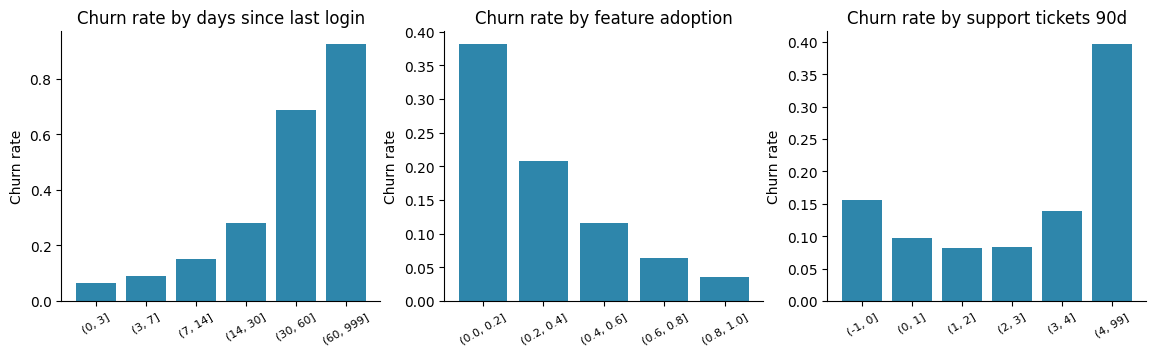

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col, bins in [(axes[0], "days_since_last_login", [0, 3, 7, 14, 30, 60, 999]),
                      (axes[1], "feature_adoption", [0, 0.2, 0.4, 0.6, 0.8, 1.0]),
                      (axes[2], "support_tickets_90d", [-1, 0, 1, 2, 3, 4, 99])]:
    rate = accounts.groupby(pd.cut(accounts[col], bins), observed=True).churned_next_90d.mean()
    ax.bar(range(len(rate)), rate.values, color="#2e86ab")
    ax.set_xticks(range(len(rate)), [str(i) for i in rate.index], rotation=30, fontsize=8)
    ax.set(title=f"Churn rate by {col.replace('_', ' ')}", ylabel="Churn rate")

Three patterns jump out:

- Churn climbs steeply the longer an account goes without logging in.
- Accounts that use more of the product churn much less.
- Support tickets are U-shaped: a couple of tickets is a *good* sign (the
  customer is engaged and getting help), but many tickets signal frustration.

A straight-line model would struggle with that last one, which is worth
remembering when we compare models.

## 2. Check for leakage first

Score every column on its own: how well does it alone separate churners
from non-churners? (AUC: 0.5 is a coin flip, 1.0 is perfect.)

In [ ]:
single_auc = {col: roc_auc_score(accounts.churned_next_90d, accounts[col])
              for col in numeric + ["refund_issued"]}
single_auc = pd.Series(single_auc).map(lambda a: max(a, 1 - a)).sort_values(ascending=False)
single_auc.round(3)

refund_issued            0.855
feature_adoption         0.723
days_since_last_login    0.718
logins_last_30d          0.702
support_tickets_90d      0.627
nps                      0.589
tenure_months            0.552
seats                    0.546
dtype: float64

`refund_issued` is far ahead of everything else, which is suspicious. And
it should be: refunds are issued *after* a customer cancels. On the snapshot
date we would never know it. Keep it in and the model would look brilliant
in testing and be useless in production, because the column is always
empty for customers who haven't cancelled yet.

Asking "would I know this value at the moment I need the prediction?" for
every column is the single most valuable habit in applied ML.

In [ ]:
features = [c for c in accounts.columns if c not in ("account_id", "churned_next_90d", "refund_issued")]
X = accounts[features].astype({c: float for c in numeric})
y = accounts.churned_next_90d
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

## 3. Two models, compared fairly

- **Logistic regression:** simple, fast and easy to explain, but it assumes
  each feature pushes churn up or down in a straight line.
- **Gradient boosting:** builds hundreds of small decision trees, each fixing
  the last one's mistakes. It can learn curves and interactions on its own.

Both get the same cross-validation folds. Because only about 1 in 7 accounts
churns, we report two scores: **ROC AUC** (how well it ranks churners above
non-churners) and **average precision** (how clean the top of the list is,
which matters more when positives are rare).

In [ ]:
encode = make_column_transformer((OneHotEncoder(drop="first"), ["plan"]), remainder=StandardScaler())
models = {
    "Logistic regression": make_pipeline(encode, LogisticRegression(max_iter=2000)),
    "Gradient boosting": make_pipeline(
        make_column_transformer((OneHotEncoder(drop="first"), ["plan"]), remainder="passthrough"),
        HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200, max_leaf_nodes=8,
                                       min_samples_leaf=40, random_state=0)),
}
folds = StratifiedKFold(5, shuffle=True, random_state=0)
for name, model in models.items():
    auc = cross_val_score(model, X_train, y_train, cv=folds, scoring="roc_auc")
    ap = cross_val_score(model, X_train, y_train, cv=folds, scoring="average_precision")
    print(f"{name:<20} ROC AUC {auc.mean():.3f} ± {auc.std():.3f}   avg precision {ap.mean():.3f} ± {ap.std():.3f}")
print(f"{'Random guessing':<20} ROC AUC 0.500           avg precision {y_train.mean():.3f}")

Logistic regression  ROC AUC 0.815 ± 0.008   avg precision 0.540 ± 0.023


Gradient boosting    ROC AUC 0.839 ± 0.015   avg precision 0.561 ± 0.024
Random guessing      ROC AUC 0.500           avg precision 0.134


In [ ]:
model = models["Gradient boosting"].fit(X_train, y_train)
scores = model.predict_proba(X_test)[:, 1]
print(f"Held-out test: ROC AUC {roc_auc_score(y_test, scores):.3f}, "
      f"avg precision {average_precision_score(y_test, scores):.3f}")

Held-out test: ROC AUC 0.845, avg precision 0.550


Gradient boosting wins, mainly because it picks up the U-shaped ticket
pattern a straight line can't. Its test score is close to its
cross-validation score, so it isn't overfitting. We'll carry it forward.

## 4. From scores to a decision

A model's output is a risk score, not an action. The action here: the
customer success team offers at-risk accounts a discount and a call. The
offer costs money, so offering it to everyone is wasteful, and offering it to
no one loses every saveable customer. Assumptions (change them to match your
business):

- Each offer costs **$150** in discount and staff time.
- A churning account is worth **$2,000** in future revenue.
- The offer saves **30%** of the churners who receive it.

So offering to an account is worth it when 30% × $2,000 × P(churn) > $150,
meaning P(churn) above 25%. Rather than trust that, let's measure profit at
every possible cut-off on the test set.

Target nobody:            $0
Target everyone:          $-104,400
Target the top 204 (14% of accounts): $37,200
  that group holds 56% of all churners; cut-off score 0.27


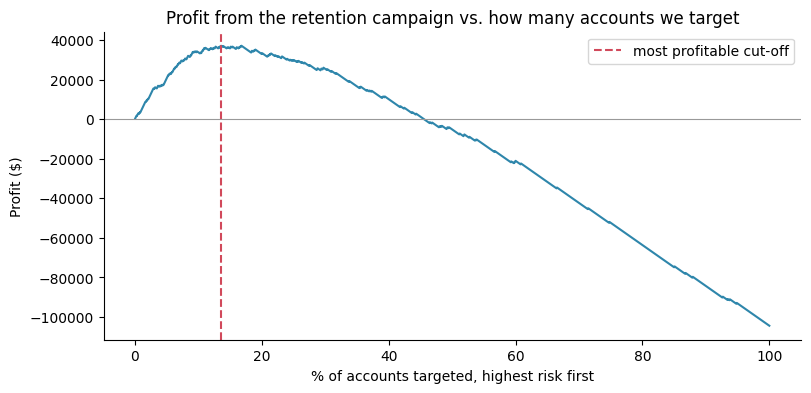

In [ ]:
OFFER_COST, ACCOUNT_VALUE, SAVE_RATE = 150, 2000, 0.30

order = np.argsort(-scores)
churners_sorted = y_test.to_numpy()[order]
n_targeted = np.arange(1, len(order) + 1)
profit = SAVE_RATE * ACCOUNT_VALUE * np.cumsum(churners_sorted) - OFFER_COST * n_targeted
best = int(np.argmax(profit))

everyone = SAVE_RATE * ACCOUNT_VALUE * y_test.sum() - OFFER_COST * len(y_test)
print("Target nobody:            $0")
print(f"Target everyone:          ${everyone:,.0f}")
print(f"Target the top {best + 1:,} ({(best + 1) / len(y_test):.0%} of accounts): ${profit[best]:,.0f}")
print(f"  that group holds {churners_sorted[:best + 1].sum() / y_test.sum():.0%} of all churners; "
      f"cut-off score {scores[order][best]:.2f}")

fig, ax = plt.subplots()
ax.plot(n_targeted / len(order) * 100, profit, color="#2e86ab")
ax.axvline((best + 1) / len(order) * 100, color="#d1495b", linestyle="--", label="most profitable cut-off")
ax.axhline(0, color="#999", linewidth=0.8)
ax.set(title="Profit from the retention campaign vs. how many accounts we target",
       xlabel="% of accounts targeted, highest risk first", ylabel="Profit ($)")
ax.legend();

Targeting everyone loses money; targeting the highest-risk slice earns the
most. Notice the cut-off isn't 0.5, and it shouldn't be. The right threshold
comes from the costs and benefits of acting, not from the model.

The same chart answers the budget question too: if the team can only make
100 calls a week, you read off the profit at that point.

## 5. What drives churn?

**Permutation importance** shuffles one column at a time and measures how
much the model's score drops. A big drop means the model leaned on that
column. It's measured on test data, so it reflects real predictive value.

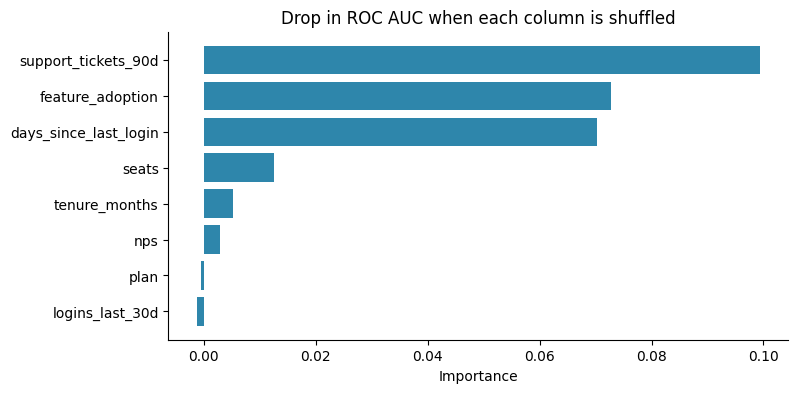

In [ ]:
imp = permutation_importance(model, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=0)
importance = pd.Series(imp.importances_mean, index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index, importance.values, color="#2e86ab")
ax.set(title="Drop in ROC AUC when each column is shuffled", xlabel="Importance");

Tickets, adoption and recency carry almost all the signal. Notice that
`logins_last_30d` scores near zero, even though churners log in far less.
That's not a contradiction: logins tell the model the same thing adoption and
recency already do, so shuffling logins alone costs nothing. Permutation
importance measures what a column adds *on top of the others*, which means
overlapping columns can look useless individually.

**Partial dependence** shows the *shape* of each effect: how predicted churn
changes as one feature moves while the others are held at their usual values.

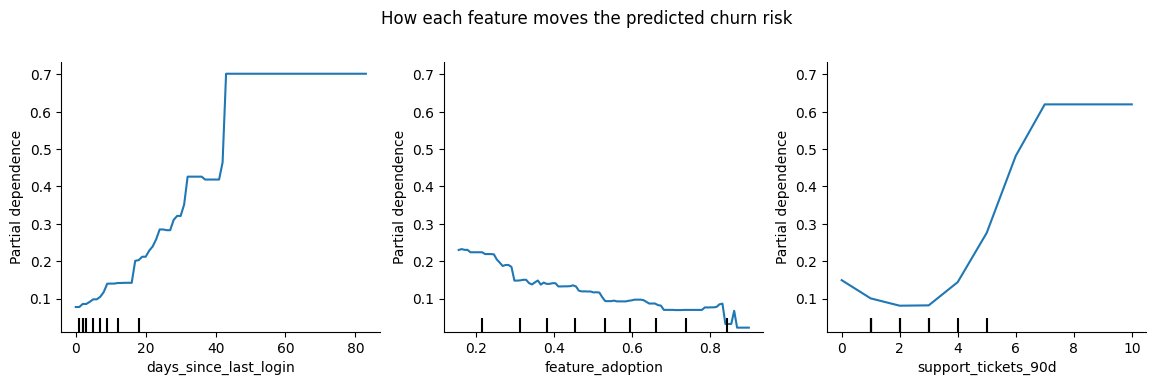

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
PartialDependenceDisplay.from_estimator(model, X_test, ["days_since_last_login", "feature_adoption",
                                                        "support_tickets_90d"], ax=ax)
fig.suptitle("How each feature moves the predicted churn risk", y=1.03);

The model has learned what we planted: inactivity and low adoption push risk
up, and support tickets lower risk up to two or three, then raise it sharply.

These are correlations, not proven causes. Low adoption might cause churn,
or both might come from a poor product fit. Still, they point at concrete
experiments: a re-engagement email after a week of inactivity, or a guided
setup that raises adoption in the first month. Run those as A/B tests (see
the game A/B testing notebook) to find out what actually works.

## Takeaways

- For every column, ask whether you'd know it at prediction time. Drop leaks.
- With rare positives, look at average precision, not just accuracy or AUC.
- Choose the threshold from business costs and benefits, never 0.5 by default.
- Permutation importance and partial dependence explain *what* the model
  learned; experiments tell you *why*.